<a href="https://colab.research.google.com/github/hodatisg520/DL4AI-240112-project/blob/main/Final_project_DL4AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
# Your code goes here

# TASK 1

## 1.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [ ]:
# 1. Hàm tạo dataset (Cập nhật từ mẫu để nhận đa biến)
def create_dataset(dataset, time_step=1, target_idx=2):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        # Lấy toàn bộ các cột (features) trong cửa sổ thời gian
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Chỉ lấy 1 cột mục tiêu để dự đoán (ví dụ cột Open - index 2)
        dataY.append(dataset[i + time_step, target_idx])
    return np.array(dataX), np.array(dataY)

In [ ]:
# 2. Đọc dữ liệu
df = pd.read_csv('AAL.csv')
# Lấy 6 đặc trưng theo yêu cầu Task 1.1
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
dataset = df[features].values
dataset = dataset.astype('float32')

In [ ]:
# 3. Chia Train/Test trước khi Scale
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

In [ ]:
# 4. Chuẩn hóa dữ liệu (Scaling)
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

# Scaler riêng cho cột Target để inverse_transform sau này
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(dataset[0:train_size, 2].reshape(-1, 1)) # Cột Open

MinMaxScaler()

In [ ]:
# 5. Tạo tập dữ liệu Train/Test
time_step = 60
target_col_idx = 2 # Dự đoán giá Open
trainX, trainY = create_dataset(train, time_step, target_col_idx)
testX, testY = create_dataset(test, time_step, target_col_idx)

In [ ]:
# 6. Xây dựng mô hình LSTM (Đúng cấu trúc Sequential trong ảnh)
model = Sequential()
# input_shape=(time_step, 6) vì ta có 6 đặc trưng đầu vào
model.add(LSTM(50, input_shape=(time_step, 6)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 7. Huấn luyện
model.fit(trainX, trainY, epochs=50, batch_size=32, verbose=2)

Epoch 1/50
107/107 - 3s - 32ms/step - loss: 0.0162
Epoch 2/50
107/107 - 2s - 15ms/step - loss: 6.3720e-04
Epoch 3/50
107/107 - 2s - 23ms/step - loss: 5.6604e-04
Epoch 4/50
107/107 - 1s - 8ms/step - loss: 5.0888e-04
Epoch 5/50
107/107 - 1s - 6ms/step - loss: 4.4277e-04
Epoch 6/50
107/107 - 1s - 6ms/step - loss: 3.9694e-04
Epoch 7/50
107/107 - 1s - 6ms/step - loss: 3.7644e-04
Epoch 8/50
107/107 - 1s - 7ms/step - loss: 3.3798e-04
Epoch 9/50
107/107 - 1s - 9ms/step - loss: 3.2632e-04
Epoch 10/50
107/107 - 1s - 9ms/step - loss: 2.8018e-04
Epoch 11/50
107/107 - 1s - 6ms/step - loss: 2.6501e-04
Epoch 12/50
107/107 - 1s - 6ms/step - loss: 2.6475e-04
Epoch 13/50
107/107 - 1s - 6ms/step - loss: 2.3877e-04
Epoch 14/50
107/107 - 1s - 6ms/step - loss: 2.1634e-04
Epoch 15/50
107/107 - 1s - 6ms/step - loss: 1.9251e-04
Epoch 16/50
107/107 - 1s - 6ms/step - loss: 1.8932e-04
Epoch 17/50
107/107 - 1s - 6ms/step - loss: 1.7010e-04
Epoch 18/50
107/107 - 1s - 6ms/step - loss: 1.6837e-04
Epoch 19/50
107/107 

In [ ]:
# 8. Dự đoán và đưa về đơn vị giá thực tế
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
from sklearn.metrics import mean_squared_error

# Get prediction on the test data (Dự đoán trên tập test đã chuẩn hóa)
y_pred_norm = model.predict(testX)

# Tính và in ra MSE trên tập test (đã chuẩn hóa) theo đúng sample code
print("MSE on the test set: ", mean_squared_error(y_pred_norm, testY))
trainPredict = target_scaler.inverse_transform(trainPredict)
testPredict = target_scaler.inverse_transform(testPredict)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE on the test set:  0.00011625869228737429


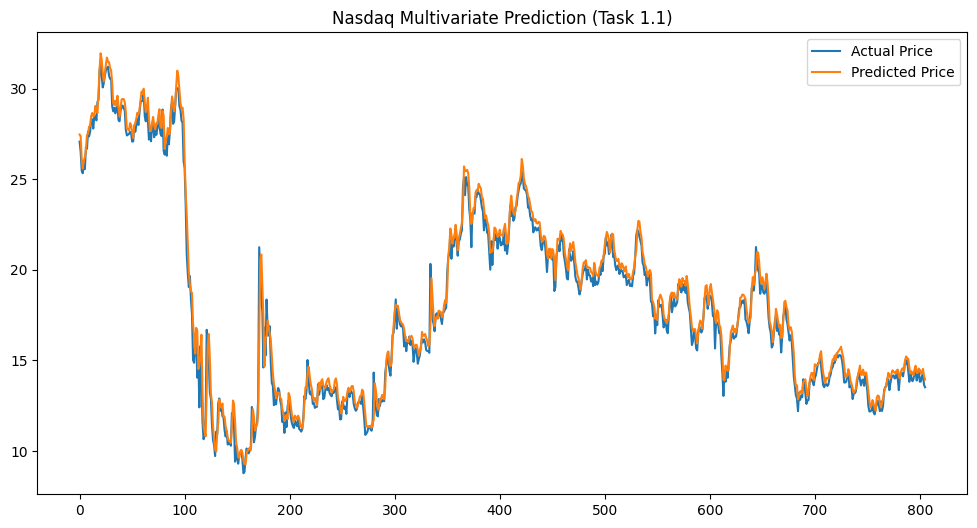

In [ ]:
# 9. Vẽ biểu đồ so sánh (Theo phong cách ảnh mẫu)
testY_plot = target_scaler.inverse_transform(testY.reshape(-1, 1))

plt.figure(figsize=(12,6))
plt.plot(testY_plot, label='Actual Price')
plt.plot(testPredict, label='Predicted Price')
plt.title('Nasdaq Multivariate Prediction (Task 1.1)')
plt.legend()
plt.show()

## 1.2

In [ ]:
def create_dataset_multivariate(dataset, time_step=1, target_idx=2, k=1):
    dataX, dataY = [], []
    # Điều chỉnh vòng lặp để lấy nhãn ở ngày thứ k
    for i in range(len(dataset) - time_step - k + 1):
        # Lấy X (vẫn là cửa sổ 60 ngày)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Lấy Y (là giá trị tại ngày thứ k sau cửa sổ X)
        dataY.append(dataset[i + time_step + k - 1, target_idx])
    return np.array(dataX), np.array(dataY)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


107/107 - 2s - 15ms/step - loss: 0.0072
Epoch 2/50
107/107 - 1s - 6ms/step - loss: 8.9478e-04
Epoch 3/50
107/107 - 1s - 6ms/step - loss: 8.5264e-04
Epoch 4/50
107/107 - 1s - 6ms/step - loss: 8.0158e-04
Epoch 5/50
107/107 - 1s - 6ms/step - loss: 8.2532e-04
Epoch 6/50
107/107 - 1s - 6ms/step - loss: 7.3546e-04
Epoch 7/50
107/107 - 1s - 6ms/step - loss: 7.0018e-04
Epoch 8/50
107/107 - 1s - 6ms/step - loss: 6.5560e-04
Epoch 9/50
107/107 - 1s - 6ms/step - loss: 6.7619e-04
Epoch 10/50
107/107 - 1s - 7ms/step - loss: 6.5997e-04
Epoch 11/50
107/107 - 1s - 8ms/step - loss: 6.2414e-04
Epoch 12/50
107/107 - 1s - 11ms/step - loss: 6.0234e-04
Epoch 13/50
107/107 - 1s - 6ms/step - loss: 6.0252e-04
Epoch 14/50
107/107 - 1s - 6ms/step - loss: 5.6146e-04
Epoch 15/50
107/107 - 1s - 5ms/step - loss: 5.6053e-04
Epoch 16/50
107/107 - 1s - 6ms/step - loss: 5.8168e-04
Epoch 17/50
107/107 - 1s - 6ms/step - loss: 5.5812e-04
Epoch 18/50
107/107 - 1s - 6ms/step - loss: 5.1341e-04
Epoch 19/50
107/107 - 1s - 6ms/s

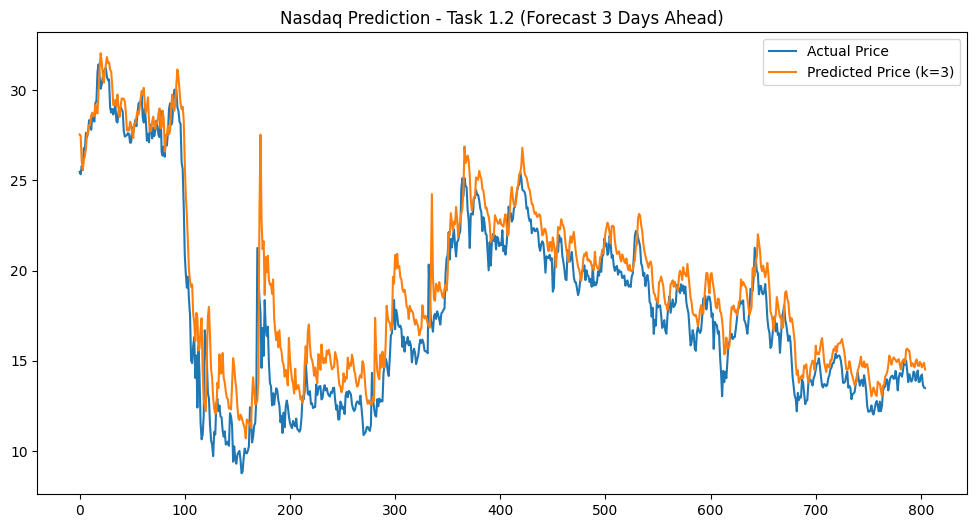

In [ ]:
# 1. Cấu hình k cho Task 1.2 (ví dụ k=3)
k_days = 3
# Sử dụng lại các biến 'train', 'test', 'time_step' và 'target_scaler' đã có từ Task 1.1

# 2. Tạo tập dữ liệu mới cho ngày thứ k
trainX_k, trainY_k = create_dataset_multivariate(train, time_step, target_idx=2, k=k_days)
testX_k, testY_k = create_dataset_multivariate(test, time_step, target_idx=2, k=k_days)

# 3. Xây dựng mô hình mới (đặt tên model_k để tránh ghi đè model cũ)
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 6)))
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện
model_k.fit(trainX_k, trainY_k, epochs=50, batch_size=32, verbose=2)

# 5. Dự đoán và đánh giá MSE trên tập test (chuẩn hóa)
y_pred_norm_k = model_k.predict(testX_k)
print(f"MSE on the test set (Normalized, k={k_days}): ", mean_squared_error(y_pred_norm_k, testY_k))

# 6. Giải mã giá thực tế và vẽ biểu đồ
y_test_real_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_real_k = target_scaler.inverse_transform(y_pred_norm_k)

plt.figure(figsize=(12,6))
plt.plot(y_test_real_k, label='Actual Price')
plt.plot(y_pred_real_k, label=f'Predicted Price (k={k_days})')
plt.title(f'Nasdaq Prediction - Task 1.2 (Forecast {k_days} Days Ahead)')
plt.legend()
plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


107/107 - 2s - 15ms/step - loss: 0.0179
Epoch 2/50
107/107 - 1s - 6ms/step - loss: 0.0018
Epoch 3/50
107/107 - 1s - 6ms/step - loss: 0.0017
Epoch 4/50
107/107 - 1s - 6ms/step - loss: 0.0017
Epoch 5/50
107/107 - 1s - 6ms/step - loss: 0.0016
Epoch 6/50
107/107 - 1s - 6ms/step - loss: 0.0016
Epoch 7/50
107/107 - 1s - 6ms/step - loss: 0.0016
Epoch 8/50
107/107 - 1s - 6ms/step - loss: 0.0015
Epoch 9/50
107/107 - 1s - 6ms/step - loss: 0.0015
Epoch 10/50
107/107 - 1s - 5ms/step - loss: 0.0015
Epoch 11/50
107/107 - 1s - 7ms/step - loss: 0.0014
Epoch 12/50
107/107 - 1s - 9ms/step - loss: 0.0014
Epoch 13/50
107/107 - 1s - 8ms/step - loss: 0.0014
Epoch 14/50
107/107 - 1s - 6ms/step - loss: 0.0015
Epoch 15/50
107/107 - 1s - 6ms/step - loss: 0.0014
Epoch 16/50
107/107 - 1s - 6ms/step - loss: 0.0014
Epoch 17/50
107/107 - 1s - 6ms/step - loss: 0.0015
Epoch 18/50
107/107 - 1s - 6ms/step - loss: 0.0015
Epoch 19/50
107/107 - 1s - 6ms/step - loss: 0.0013
Epoch 20/50
107/107 - 1s - 6ms/step - loss: 0.0014

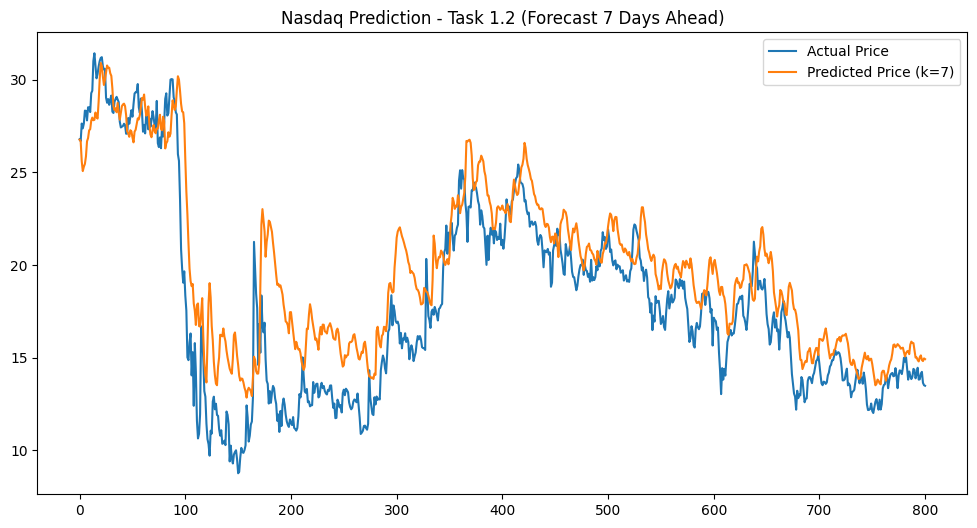

In [ ]:
# 1. Cấu hình k cho Task 1.2 (ví dụ k=3)
k_days = 7
# Sử dụng lại các biến 'train', 'test', 'time_step' và 'target_scaler' đã có từ Task 1.1

# 2. Tạo tập dữ liệu mới cho ngày thứ k
trainX_k, trainY_k = create_dataset_multivariate(train, time_step, target_idx=2, k=k_days)
testX_k, testY_k = create_dataset_multivariate(test, time_step, target_idx=2, k=k_days)

# 3. Xây dựng mô hình mới (đặt tên model_k để tránh ghi đè model cũ)
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 6)))
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện
model_k.fit(trainX_k, trainY_k, epochs=50, batch_size=32, verbose=2)

# 5. Dự đoán và đánh giá MSE trên tập test (chuẩn hóa)
y_pred_norm_k = model_k.predict(testX_k)
print(f"MSE on the test set (Normalized, k={k_days}): ", mean_squared_error(y_pred_norm_k, testY_k))

# 6. Giải mã giá thực tế và vẽ biểu đồ
y_test_real_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_real_k = target_scaler.inverse_transform(y_pred_norm_k)

plt.figure(figsize=(12,6))
plt.plot(y_test_real_k, label='Actual Price')
plt.plot(y_pred_real_k, label=f'Predicted Price (k={k_days})')
plt.title(f'Nasdaq Prediction - Task 1.2 (Forecast {k_days} Days Ahead)')
plt.legend()
plt.show()

## 1.3

In [ ]:
def create_dataset_sequence(dataset, time_step=60, target_idx=2, k=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # X: Lấy cửa sổ thời gian như bình thường (ví dụ 60 ngày)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)

        # Y: Lấy một mảng liên tục k ngày tiếp theo
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])

    return np.array(dataX), np.array(dataY)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


107/107 - 2s - 15ms/step - loss: 0.0399
Epoch 2/50
107/107 - 1s - 6ms/step - loss: 0.0011
Epoch 3/50
107/107 - 1s - 5ms/step - loss: 0.0010
Epoch 4/50
107/107 - 1s - 6ms/step - loss: 9.5164e-04
Epoch 5/50
107/107 - 1s - 5ms/step - loss: 8.6089e-04
Epoch 6/50
107/107 - 1s - 6ms/step - loss: 7.6927e-04
Epoch 7/50
107/107 - 1s - 6ms/step - loss: 7.5840e-04
Epoch 8/50
107/107 - 1s - 6ms/step - loss: 6.6509e-04
Epoch 9/50
107/107 - 1s - 6ms/step - loss: 6.5792e-04
Epoch 10/50
107/107 - 1s - 6ms/step - loss: 6.2890e-04
Epoch 11/50
107/107 - 1s - 6ms/step - loss: 5.8412e-04
Epoch 12/50
107/107 - 1s - 6ms/step - loss: 5.6493e-04
Epoch 13/50
107/107 - 1s - 6ms/step - loss: 5.2710e-04
Epoch 14/50
107/107 - 1s - 6ms/step - loss: 5.2058e-04
Epoch 15/50
107/107 - 1s - 9ms/step - loss: 5.3709e-04
Epoch 16/50
107/107 - 1s - 8ms/step - loss: 4.6413e-04
Epoch 17/50
107/107 - 1s - 7ms/step - loss: 4.5712e-04
Epoch 18/50
107/107 - 1s - 6ms/step - loss: 4.4044e-04
Epoch 19/50
107/107 - 1s - 5ms/step - los

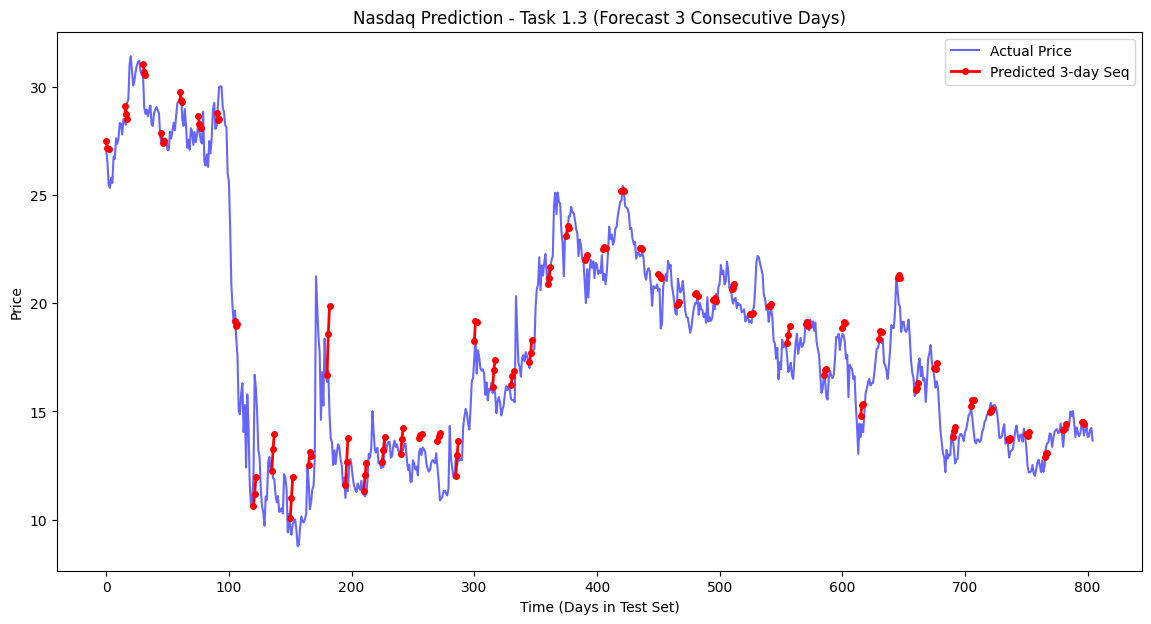

In [ ]:
# 1. Cấu hình k cho Task 1.3 (ví dụ dự báo chuỗi 3 ngày liên tiếp)
k_seq = 3

# 2. Tạo tập dữ liệu chuỗi (Sử dụng lại biến train/test từ 1.1)
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=2, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=2, k=k_seq)

# 3. Xây dựng mô hình chuỗi (Model_seq)
model_seq = Sequential()
model_seq.add(LSTM(50, input_shape=(time_step, 6)))

# ĐIỂM QUAN TRỌNG: Lớp Dense phải có số unit bằng số ngày k_seq
model_seq.add(Dense(k_seq))
model_seq.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện mô hình
model_seq.fit(trainX_seq, trainY_seq, epochs=50, batch_size=32, verbose=2)

# 5. Dự đoán và Đánh giá
y_pred_norm_seq = model_seq.predict(testX_seq)

# In ra MSE trên tập chuẩn hóa
print(f"MSE on the test set (Normalized, Sequence k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Khôi phục giá trị thực (De-normalization)
# Vì testY_seq và y_pred_norm_seq giờ là mảng 2D (N, k), ta cần flatten (.reshape(-1, 1))
# trước khi inverse_transform, sau đó reshape lại về dạng (N, k) ban đầu.
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# 7. Vẽ biểu đồ (Đặc thù cho chuỗi liên tiếp)
plt.figure(figsize=(14, 7))

# Vẽ đường giá thực tế liền mạch (chỉ lấy ngày đầu tiên của mỗi chuỗi Y để nối thành đường)
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price', alpha=0.6)

# Vẽ các đoạn dự báo chuỗi (cứ cách 15 ngày vẽ 1 đoạn để đồ thị không bị rối)
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    # Trục X cho k ngày
    x_axis = range(i, i + k_seq)

    # Gắn label cho đoạn đầu tiên để hiện trong chú thích (legend), các đoạn sau ẩn label
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Nasdaq Prediction - Task 1.3 (Forecast {k_seq} Consecutive Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
def create_dataset_sequence(dataset, time_step=60, target_idx=2, k=7):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # X: Lấy cửa sổ thời gian như bình thường (ví dụ 60 ngày)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)

        # Y: Lấy một mảng liên tục k ngày tiếp theo
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])

    return np.array(dataX), np.array(dataY)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


107/107 - 2s - 22ms/step - loss: 0.0277
Epoch 2/50
107/107 - 1s - 6ms/step - loss: 0.0013
Epoch 3/50
107/107 - 1s - 6ms/step - loss: 0.0012
Epoch 4/50
107/107 - 1s - 6ms/step - loss: 0.0011
Epoch 5/50
107/107 - 1s - 6ms/step - loss: 0.0011
Epoch 6/50
107/107 - 1s - 6ms/step - loss: 0.0011
Epoch 7/50
107/107 - 1s - 6ms/step - loss: 0.0010
Epoch 8/50
107/107 - 1s - 6ms/step - loss: 9.9325e-04
Epoch 9/50
107/107 - 1s - 6ms/step - loss: 9.5725e-04
Epoch 10/50
107/107 - 1s - 6ms/step - loss: 9.2846e-04
Epoch 11/50
107/107 - 1s - 6ms/step - loss: 9.3129e-04
Epoch 12/50
107/107 - 1s - 6ms/step - loss: 8.8707e-04
Epoch 13/50
107/107 - 1s - 6ms/step - loss: 9.0742e-04
Epoch 14/50
107/107 - 1s - 6ms/step - loss: 8.8475e-04
Epoch 15/50
107/107 - 1s - 6ms/step - loss: 8.5745e-04
Epoch 16/50
107/107 - 1s - 6ms/step - loss: 8.6593e-04
Epoch 17/50
107/107 - 1s - 8ms/step - loss: 8.5334e-04
Epoch 18/50
107/107 - 1s - 9ms/step - loss: 8.4987e-04
Epoch 19/50
107/107 - 1s - 8ms/step - loss: 8.2328e-04
Ep

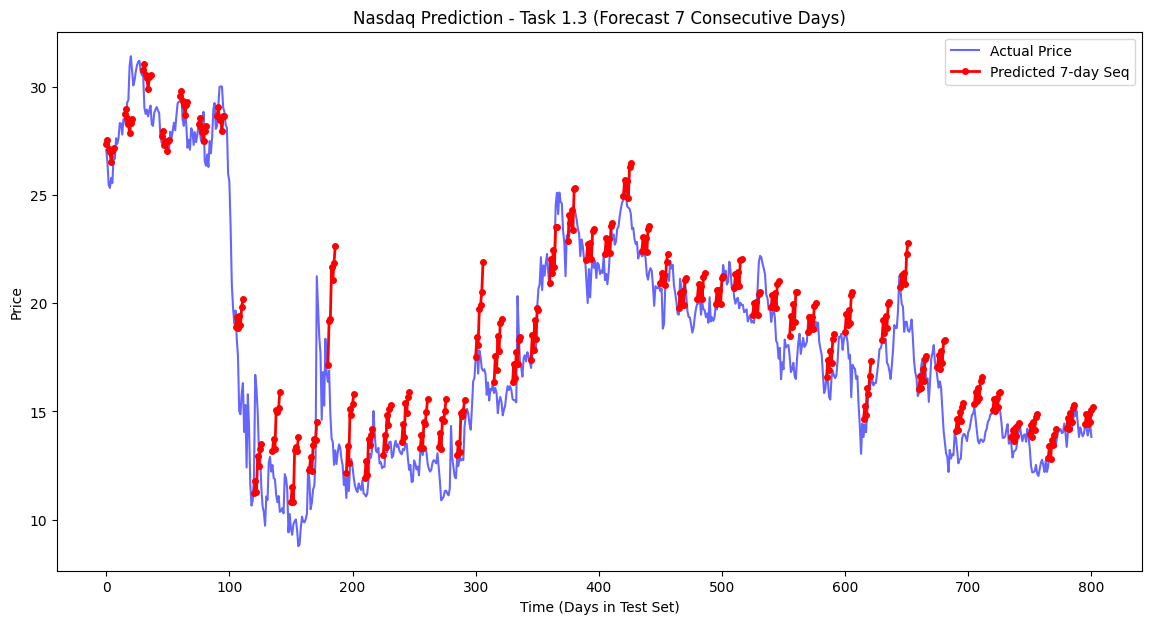

In [ ]:
# 1. Cấu hình k cho Task 1.3 (ví dụ dự báo chuỗi 3 ngày liên tiếp)
k_seq = 7

# 2. Tạo tập dữ liệu chuỗi (Sử dụng lại biến train/test từ 1.1)
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=2, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=2, k=k_seq)

# 3. Xây dựng mô hình chuỗi (Model_seq)
model_seq = Sequential()
model_seq.add(LSTM(50, input_shape=(time_step, 6)))

# ĐIỂM QUAN TRỌNG: Lớp Dense phải có số unit bằng số ngày k_seq
model_seq.add(Dense(k_seq))
model_seq.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện mô hình
model_seq.fit(trainX_seq, trainY_seq, epochs=50, batch_size=32, verbose=2)

# 5. Dự đoán và Đánh giá
y_pred_norm_seq = model_seq.predict(testX_seq)

# In ra MSE trên tập chuẩn hóa
print(f"MSE on the test set (Normalized, Sequence k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Khôi phục giá trị thực (De-normalization)
# Vì testY_seq và y_pred_norm_seq giờ là mảng 2D (N, k), ta cần flatten (.reshape(-1, 1))
# trước khi inverse_transform, sau đó reshape lại về dạng (N, k) ban đầu.
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# 7. Vẽ biểu đồ (Đặc thù cho chuỗi liên tiếp)
plt.figure(figsize=(14, 7))

# Vẽ đường giá thực tế liền mạch (chỉ lấy ngày đầu tiên của mỗi chuỗi Y để nối thành đường)
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price', alpha=0.6)

# Vẽ các đoạn dự báo chuỗi (cứ cách 15 ngày vẽ 1 đoạn để đồ thị không bị rối)
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    # Trục X cho k ngày
    x_axis = range(i, i + k_seq)

    # Gắn label cho đoạn đầu tiên để hiện trong chú thích (legend), các đoạn sau ẩn label
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Nasdaq Prediction - Task 1.3 (Forecast {k_seq} Consecutive Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price')
plt.legend()
plt.show()

# TASK 2

## 2.1

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [57]:
# 1. Hàm tạo dataset đa biến (Dùng chung kiến trúc từ Task 1)
def create_dataset(dataset, time_step=1, target_idx=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        # Lấy toàn bộ các cột (features) trong cửa sổ thời gian
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Lấy 1 cột mục tiêu để dự đoán
        dataY.append(dataset[i + time_step, target_idx])
    return np.array(dataX), np.array(dataY)

In [58]:
# 2. Đọc dữ liệu Việt Nam (File SAM)
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data-vn-20230228/stock-historical-data/SAM-VNINDEX-History.csv'
df = pd.read_csv(file_path)

# MẸO NHỎ NHƯNG QUAN TRỌNG VỚI DATA VIỆT NAM:
# Dữ liệu tải từ các nguồn VN thường xếp ngày mới nhất ở trên cùng.
# Ta cần đảo ngược lại (từ cũ đến mới) để chuỗi thời gian đi đúng hướng.
if 'TradingDate' in df.columns:
    df['TradingDate'] = pd.to_datetime(df['TradingDate'])
    df = df.sort_values('TradingDate').reset_index(drop=True)

# Lọc 5 đặc trưng (Bỏ qua Adjusted Close vì file không có)
features_vn = ['Low', 'High', 'Open', 'Close', 'Volume']
dataset = df[features_vn].values
dataset = dataset.astype('float32')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# 3. Chia Train/Test (Chia TRƯỚC, Scale SAU để chống Data Leakage)
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

In [60]:
# 4. Chuẩn hóa dữ liệu (Scaling)
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

# Scaler riêng cho cột Target (Ở đây ta dự đoán 'Close' - nằm ở index 3 trong danh sách features_vn)
target_idx = 3
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(dataset[0:train_size, target_idx].reshape(-1, 1))

MinMaxScaler()

In [61]:
# 5. Tạo tập dữ liệu Train/Test
time_step = 30
trainX, trainY = create_dataset(train, time_step, target_idx)
testX, testY = create_dataset(test, time_step, target_idx)

In [62]:
# 6. Xây dựng mô hình LSTM (Sửa input_shape về 5 features)
model = Sequential()
# input_shape=(time_step, 5) vì dữ liệu VN lần này chỉ có 5 đặc trưng đầu vào
model.add(LSTM(50, input_shape=(time_step, 5)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [63]:
# 7. Huấn luyện mô hình
model.fit(trainX, trainY, epochs=50, batch_size=32, verbose=2)

Epoch 1/50
135/135 - 4s - 30ms/step - loss: 0.0032
Epoch 2/50
135/135 - 1s - 9ms/step - loss: 3.0231e-04
Epoch 3/50
135/135 - 1s - 9ms/step - loss: 2.6034e-04
Epoch 4/50
135/135 - 1s - 8ms/step - loss: 2.2521e-04
Epoch 5/50
135/135 - 1s - 10ms/step - loss: 1.9673e-04
Epoch 6/50
135/135 - 2s - 11ms/step - loss: 1.7698e-04
Epoch 7/50
135/135 - 2s - 17ms/step - loss: 1.6363e-04
Epoch 8/50
135/135 - 1s - 10ms/step - loss: 1.5292e-04
Epoch 9/50
135/135 - 1s - 9ms/step - loss: 1.4399e-04
Epoch 10/50
135/135 - 1s - 9ms/step - loss: 1.3638e-04
Epoch 11/50
135/135 - 1s - 9ms/step - loss: 1.2984e-04
Epoch 12/50
135/135 - 1s - 10ms/step - loss: 1.2419e-04
Epoch 13/50
135/135 - 1s - 9ms/step - loss: 1.1925e-04
Epoch 14/50
135/135 - 1s - 10ms/step - loss: 1.1483e-04
Epoch 15/50
135/135 - 2s - 17ms/step - loss: 1.1079e-04
Epoch 16/50
135/135 - 1s - 9ms/step - loss: 1.0703e-04
Epoch 17/50
135/135 - 1s - 9ms/step - loss: 1.0349e-04
Epoch 18/50
135/135 - 1s - 10ms/step - loss: 1.0016e-04
Epoch 19/50
13

In [64]:
# 8. Dự đoán và Tính MSE theo Sample Code
y_pred_norm = model.predict(testX)

# In MSE trên tập Test (đã chuẩn hóa) để giảng viên chấm điểm
print("MSE on the test set (Normalized VN Data): ", mean_squared_error(y_pred_norm, testY))

# Khôi phục giá trị về tiền thật (VNĐ)
y_test_rescaled = target_scaler.inverse_transform(testY.reshape(-1, 1))
y_pred_rescaled = target_scaler.inverse_transform(y_pred_norm)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MSE on the test set (Normalized VN Data):  0.00022020586766302586


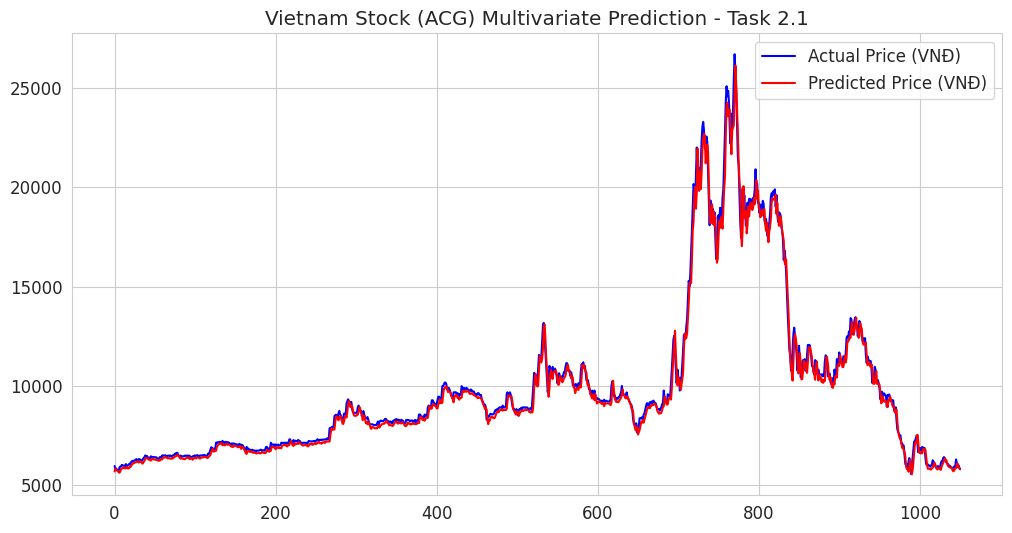

In [65]:
# 9. Vẽ biểu đồ so sánh
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label='Actual Price (VNĐ)', color='blue')
plt.plot(y_pred_rescaled, label='Predicted Price (VNĐ)', color='red')
plt.title('Vietnam Stock (ACG) Multivariate Prediction - Task 2.1')
plt.legend()
plt.show()

## 2.2

In [67]:
def create_dataset_kth_day(dataset, time_step=30, target_idx=3, k=3):
    """
    k: số ngày trong tương lai muốn dự đoán.
    Với dữ liệu VN, target_idx = 3 (cột Close).
    """
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # Lấy 30 ngày quá khứ, đủ 5 features (Low, High, Open, Close, Volume)
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        # Lấy giá trị của cột Target ở "k" ngày sau đó
        dataY.append(dataset[i + time_step + k - 1, target_idx])
    return np.array(dataX), np.array(dataY)

In [68]:
# 1. Cấu hình k (Thay đổi thành 7 nếu muốn dự đoán ngày thứ 7)
k_days_ahead = 3

# 2. Tạo tập dữ liệu (Tái sử dụng 'train', 'test', 'time_step', 'target_idx' từ Task 2.1)
trainX_k, trainY_k = create_dataset_kth_day(train, time_step, target_idx, k=k_days_ahead)
testX_k, testY_k = create_dataset_kth_day(test, time_step, target_idx, k=k_days_ahead)

In [69]:
# 3. Khởi tạo mô hình mới (Tên model_k để không ghi đè model của task 2.1)
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 5))) # 5 features của chứng khoán VN
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

In [70]:
# 4. Huấn luyện
print(f"\n--- Đang huấn luyện dự đoán ngày thứ {k_days_ahead} (Mã SAM) ---")
model_k.fit(trainX_k, trainY_k, epochs=50, batch_size=32, verbose=2)


--- Đang huấn luyện dự đoán ngày thứ 3 (Mã SAM) ---
Epoch 1/50
135/135 - 4s - 30ms/step - loss: 0.0016
Epoch 2/50
135/135 - 2s - 14ms/step - loss: 3.8172e-04
Epoch 3/50
135/135 - 2s - 14ms/step - loss: 3.6110e-04
Epoch 4/50
135/135 - 1s - 10ms/step - loss: 3.4161e-04
Epoch 5/50
135/135 - 1s - 10ms/step - loss: 3.2490e-04
Epoch 6/50
135/135 - 1s - 10ms/step - loss: 3.1118e-04
Epoch 7/50
135/135 - 1s - 8ms/step - loss: 2.9994e-04
Epoch 8/50
135/135 - 1s - 8ms/step - loss: 2.9053e-04
Epoch 9/50
135/135 - 1s - 9ms/step - loss: 2.8243e-04
Epoch 10/50
135/135 - 2s - 15ms/step - loss: 2.7530e-04
Epoch 11/50
135/135 - 2s - 13ms/step - loss: 2.6893e-04
Epoch 12/50
135/135 - 1s - 9ms/step - loss: 2.6317e-04
Epoch 13/50
135/135 - 1s - 8ms/step - loss: 2.5793e-04
Epoch 14/50
135/135 - 1s - 9ms/step - loss: 2.5313e-04
Epoch 15/50
135/135 - 1s - 8ms/step - loss: 2.4872e-04
Epoch 16/50
135/135 - 1s - 9ms/step - loss: 2.4465e-04
Epoch 17/50
135/135 - 1s - 10ms/step - loss: 2.4089e-04
Epoch 18/50
135/

In [71]:
# 5. Dự đoán và in MSE
y_pred_norm_k = model_k.predict(testX_k)
print(f"\nMSE on the test set (Normalized SAM Data, k={k_days_ahead}): ", mean_squared_error(testY_k, y_pred_norm_k))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

MSE on the test set (Normalized SAM Data, k=3):  0.0006340957479551435


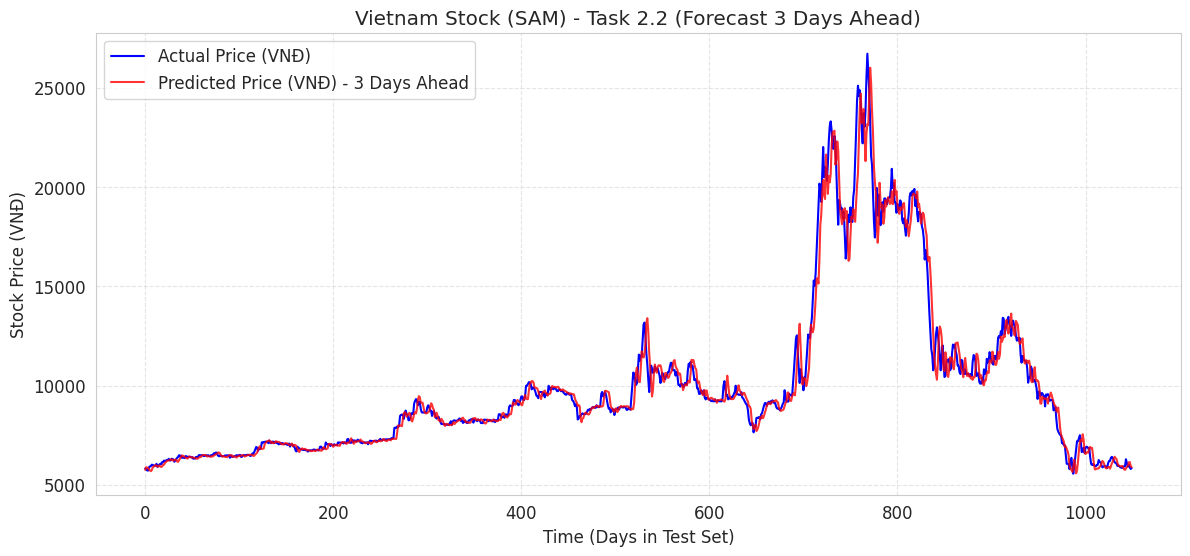

In [72]:
# 6. Khôi phục giá trị thực tế (Tái sử dụng target_scaler từ Task 2.1)
y_test_rescaled_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_rescaled_k = target_scaler.inverse_transform(y_pred_norm_k)

# 7. Vẽ biểu đồ
plt.figure(figsize=(14,6))
plt.plot(y_test_rescaled_k, label='Actual Price (VNĐ)', color='blue', linewidth=1.5)
plt.plot(y_pred_rescaled_k, label=f'Predicted Price (VNĐ) - {k_days_ahead} Days Ahead', color='red', linewidth=1.5, alpha=0.8)
plt.title(f'Vietnam Stock (SAM) - Task 2.2 (Forecast {k_days_ahead} Days Ahead)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (VNĐ)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2.3

In [74]:
# Hàm tạo dataset dự đoán một chuỗi k ngày liên tiếp
def create_dataset_sequence(dataset, time_step=30, target_idx=3, k=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        # Lấy X: Cửa sổ 30 ngày quá khứ, 5 features
        a = dataset[i:(i + time_step), :]
        dataX.append(a)

        # Lấy Y: MỘT CHUỖI k ngày liên tiếp sau cửa sổ X
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])

    return np.array(dataX), np.array(dataY)


--- Đang huấn luyện mô hình (time_step=30, k_seq=3) ---
Epoch 1/50
135/135 - 3s - 23ms/step - loss: 0.0043
Epoch 2/50
135/135 - 2s - 17ms/step - loss: 3.9498e-04
Epoch 3/50
135/135 - 1s - 10ms/step - loss: 3.4373e-04
Epoch 4/50
135/135 - 1s - 8ms/step - loss: 3.1273e-04
Epoch 5/50
135/135 - 1s - 7ms/step - loss: 2.9108e-04
Epoch 6/50
135/135 - 1s - 10ms/step - loss: 2.7388e-04
Epoch 7/50
135/135 - 1s - 8ms/step - loss: 2.5939e-04
Epoch 8/50
135/135 - 2s - 12ms/step - loss: 2.4688e-04
Epoch 9/50
135/135 - 2s - 14ms/step - loss: 2.3599e-04
Epoch 10/50
135/135 - 1s - 9ms/step - loss: 2.2649e-04
Epoch 11/50
135/135 - 1s - 9ms/step - loss: 2.1818e-04
Epoch 12/50
135/135 - 1s - 10ms/step - loss: 2.1090e-04
Epoch 13/50
135/135 - 1s - 9ms/step - loss: 2.0450e-04
Epoch 14/50
135/135 - 1s - 9ms/step - loss: 1.9883e-04
Epoch 15/50
135/135 - 1s - 9ms/step - loss: 1.9378e-04
Epoch 16/50
135/135 - 1s - 8ms/step - loss: 1.8925e-04
Epoch 17/50
135/135 - 1s - 7ms/step - loss: 1.8515e-04
Epoch 18/50
13

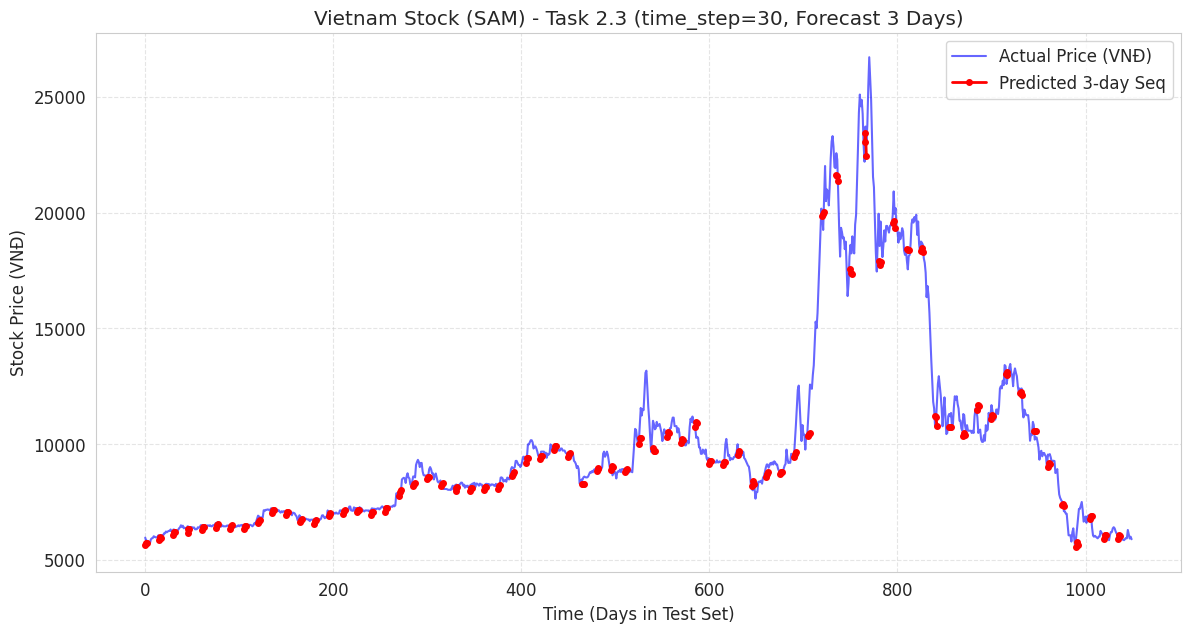

In [75]:
# 1. Cập nhật cấu hình cửa sổ thời gian
time_step = 30  # Đã đổi thành 30 ngày theo yêu cầu
k_seq = 3       # Dự đoán chuỗi 3 ngày liên tiếp

# 2. Tạo tập dữ liệu chuỗi MỚI với time_step = 30
# (Vẫn tận dụng lại biến 'train' và 'test' đã chuẩn hóa từ Task 2.1)
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=3, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=3, k=k_seq)

# 3. Khởi tạo mô hình với input_shape mới
model_seq_vn = Sequential()
# model sẽ tự động nhận input_shape là (30, 5)
model_seq_vn.add(LSTM(50, input_shape=(time_step, 5)))
model_seq_vn.add(Dense(k_seq))
model_seq_vn.compile(loss='mean_squared_error', optimizer='adam')

# 4. Huấn luyện mô hình
print(f"\n--- Đang huấn luyện mô hình (time_step={time_step}, k_seq={k_seq}) ---")
model_seq_vn.fit(trainX_seq, trainY_seq, epochs=50, batch_size=32, verbose=2)

# 5. Dự đoán và in điểm MSE
y_pred_norm_seq = model_seq_vn.predict(testX_seq)
print(f"\nMSE on the test set (Normalized, time_step={time_step}, k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Khôi phục giá trị thực
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# 7. Vẽ biểu đồ
plt.figure(figsize=(14, 7))

# Vẽ đường giá thực tế liền mạch
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price (VNĐ)', alpha=0.6, linewidth=1.5)

# Vẽ các đoạn rẽ nhánh dự báo
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    x_axis = range(i, i + k_seq)
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Vietnam Stock (SAM) - Task 2.3 (time_step={time_step}, Forecast {k_seq} Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (VNĐ)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()